<a href="https://colab.research.google.com/github/Vel-Pandi-Meena-18/Assignment_3/blob/main/Ecotype_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cover_type (1).csv to cover_type (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("cover_type (1).csv")

In [ ]:
df.shape

(145890, 13)

In [ ]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
(df == 0).sum()

,0
Elevation,0
Aspect,1596
Slope,244
Horizontal_Distance_To_Hydrology,7157
Vertical_Distance_To_Hydrology,11397
Horizontal_Distance_To_Roadways,3
Hillshade_9am,1
Hillshade_Noon,0
Hillshade_3pm,118
Horizontal_Distance_To_Fire_Points,7


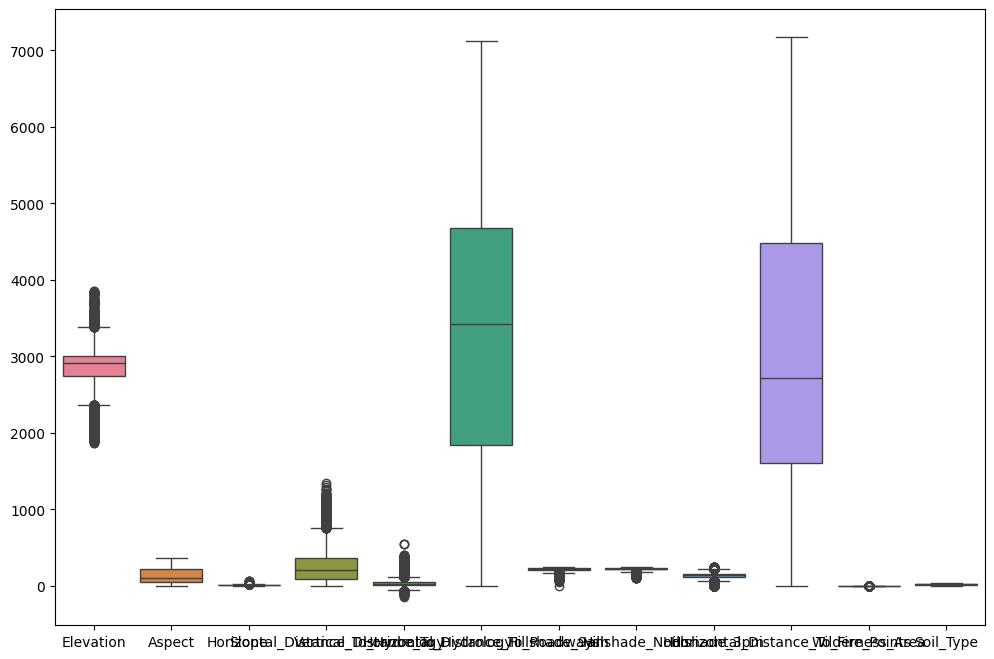

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.show()

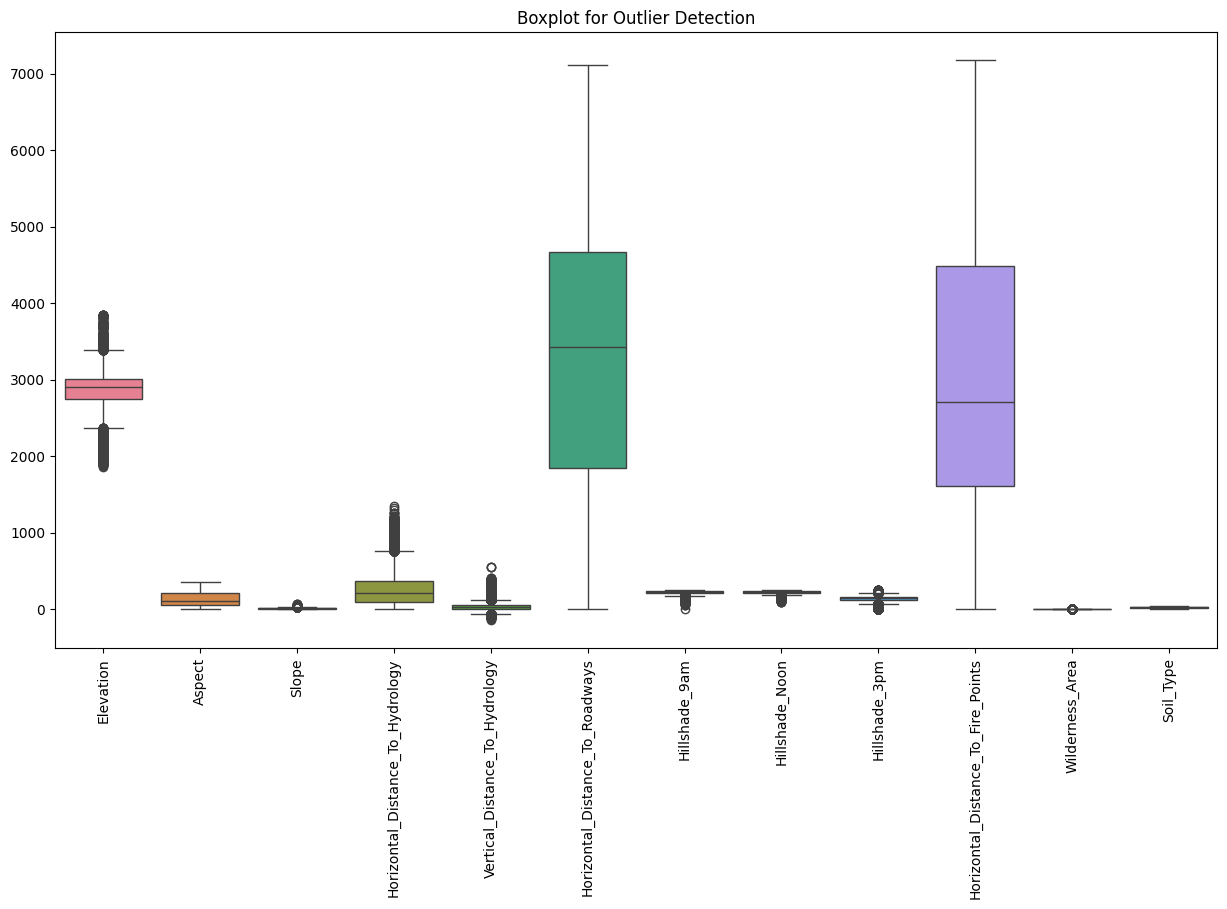

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [ ]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

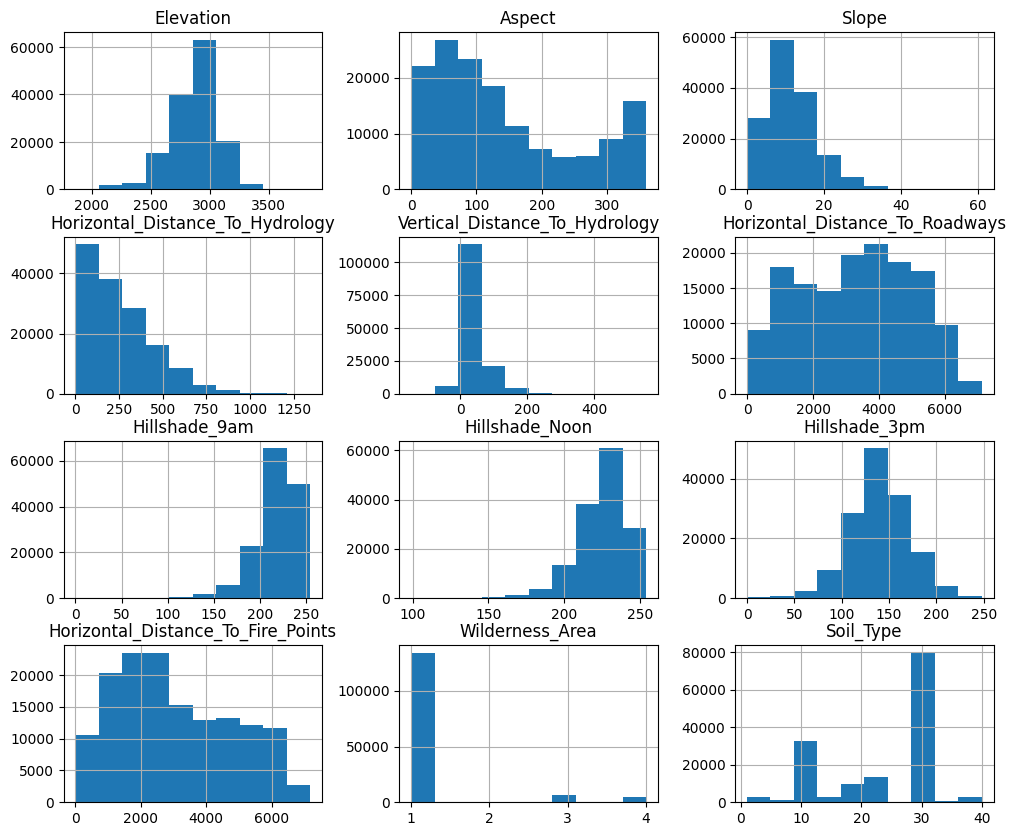

In [ ]:
df.hist(figsize=(12,10))
plt.show()


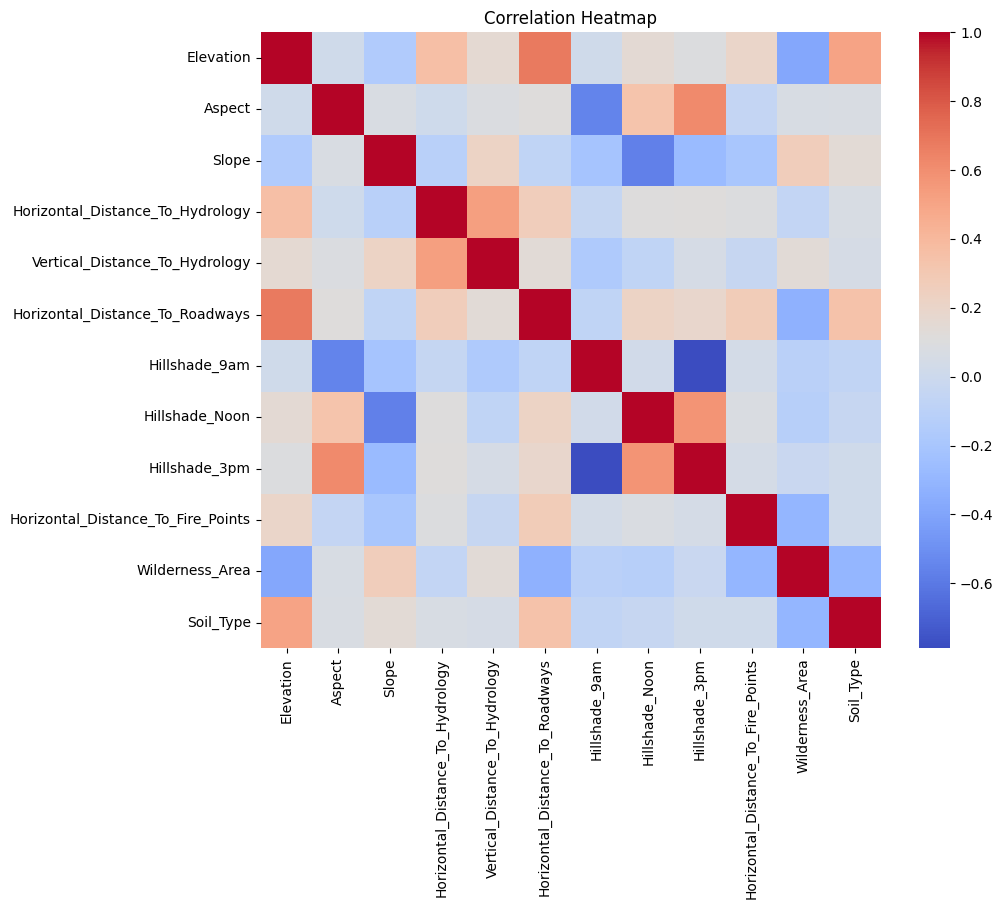

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

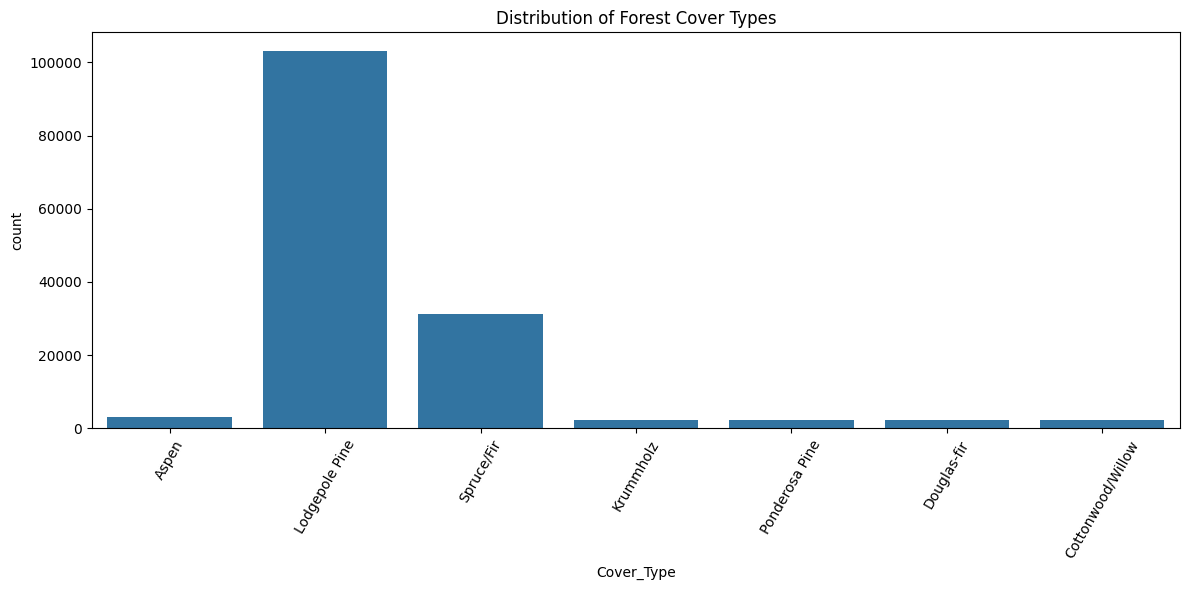

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x="Cover_Type", data=df)
plt.title("Distribution of Forest Cover Types")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

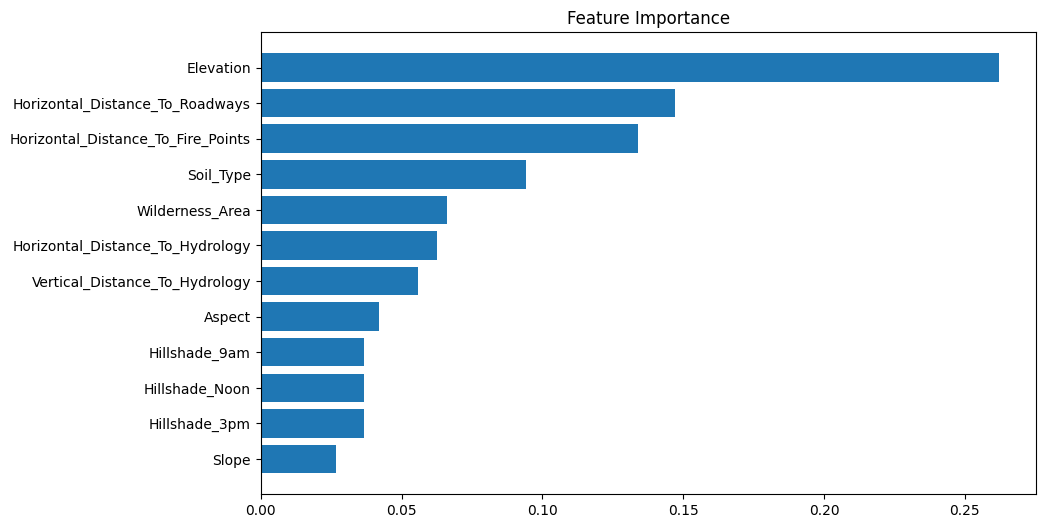

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": df.drop("Cover_Type", axis=1).columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [ ]:
X = pd.get_dummies(X, drop_first=True) ## encoding

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE  ##Class Imbalance Handling (SMOTE)

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
import pandas as pd
pd.Series(y_train).value_counts()

,count
Cover_Type,
Lodgepole Pine,82362
Spruce/Fir,82362
Cottonwood/Willow,82362
Ponderosa Pine,82362
Douglas-fir,82362
Aspen,82362
Krummholz,82362


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

                               Feature  Importance
0                            Elevation    0.242363
11                           Soil_Type    0.158463
5      Horizontal_Distance_To_Roadways    0.118207
10                     Wilderness_Area    0.098249
9   Horizontal_Distance_To_Fire_Points    0.092432
3     Horizontal_Distance_To_Hydrology    0.066609
4       Vertical_Distance_To_Hydrology    0.046929
6                        Hillshade_9am    0.045116
1                               Aspect    0.039011
8                        Hillshade_3pm    0.033392
7                       Hillshade_Noon    0.030614
2                                Slope    0.028616


In [ ]:
threshold = 0.01

In [ ]:
selected_features = feature_importance[feature_importance["Importance"] > 0.01]["Feature"]

X = X[selected_features]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode target only for XGBoost
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

results = {}

for name, model in models.items():
    print("\n" + "="*60)
    print(f"Training {name}...")

    # XGBoost uses encoded target
    if name == "XGBoost":
        model.fit(X_train, y_train_enc)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test_enc, y_pred)
        print(f"{name} Accuracy: {acc:.4f}")
        print("\nClassification Report:\n")
        print(classification_report(y_test_enc, y_pred))
        print("\nConfusion Matrix:\n")
        print(confusion_matrix(y_test_enc, y_pred))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"{name} Accuracy: {acc:.4f}")
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))
        print("\nConfusion Matrix:\n")
        print(confusion_matrix(y_test, y_pred))

    results[name] = acc

print("\n" + "="*60)
print("FINAL ACCURACY COMPARISON")
print("="*60)

for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


Training Logistic Regression...
Logistic Regression Accuracy: 0.8222

Classification Report:

                   precision    recall  f1-score   support

            Aspen       0.54      0.27      0.36       580
Cottonwood/Willow       0.77      0.84      0.81       423
      Douglas-fir       0.63      0.59      0.61       440
        Krummholz       0.83      0.84      0.83       405
   Lodgepole Pine       0.84      0.96      0.90     20709
   Ponderosa Pine       0.56      0.55      0.56       402
       Spruce/Fir       0.78      0.45      0.57      6219

         accuracy                           0.82     29178
        macro avg       0.71      0.64      0.66     29178
     weighted avg       0.81      0.82      0.80     29178


Confusion Matrix:

[[  157     0    17     0   394    12     0]
 [    0   357    16     0     0    50     0]
 [   13    52   261     0     6   108     0]
 [    1     0     0   340     0     0    64]
 [   69     1    15     8 19875     5   736]
 [   13 

## Hyperparameter Tuning


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print("Best Parameters:", random_search.best_params_)

Tuned Accuracy: 0.9546918911508671
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [ ]:
import pickle

# Save best model
with open("forest_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

# Save scaler (important for Streamlit later)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
with open("model_features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [ ]:
import pickle

with open("model_features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [ ]:
from google.colab import files
files.download("forest_model.pkl")
files.download("scaler.pkl")
files.download("model_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>